In [1]:
import sys
sys.path.insert(0, "/srv/user/azhar.akhmetova/corrViT/analysis/src")
import os
import pickle
import matplotlib
import numpy as np
import typing as t
import argparse
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.ndimage import center_of_mass

from v1t.utils import utils, tensorboard
from v1t import data
from v1t.models.model import Model
from v1t.utils.scheduler import Scheduler
from v1t.utils.attention_rollout import extract_attention_maps

from torch.utils.data import DataLoader

utils.set_random_seed(1234)

tensorboard.set_font()

## Load the model, its embeddings and attention maps

In [9]:
out_dir = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_scheduled/k_4_a_03_xyz_randsched_nosubsel_bits_1dLL_lrx04_noinit_LLbias_meanbias_s_1_frac0_05_2dpe_bef_core"

In [10]:
parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="/user/azhar.akhmetova/corrViT/refactor/data/sensorium")
parser.add_argument("--output_dir", type=str, required=True)
parser.add_argument("--batch_size", type=int, default=1)
parser.add_argument("--device", type=str, default="cpu")

args = parser.parse_args([
    "--output_dir", f"{out_dir}",#"/user/azhar.akhmetova/corrViT/runs_debug/stabilized-training/k_4_no_subselect/k_4_a_03_nosubsel_bits_regfeatures_lrx04_noinit_LLbias_meanbias_s_1_frac0_1_2dpe_bef_core",
])

In [11]:
if not os.path.isdir(args.output_dir):
    raise FileNotFoundError(f"Cannot find {args.output_dir}.")

utils.get_device(args)
utils.set_random_seed(1234)

utils.load_args(args)

train_ds, val_ds, test_ds = data.get_training_ds(
    args,
    data_dir=args.dataset,
    mouse_ids=args.mouse_ids,
    batch_size=args.batch_size,
    device=args.device,
)

model = Model(args, ds=val_ds)
model.eval()

scheduler = Scheduler(args, model=model, save_optimizer=False)
scheduler.restore(force=True)

image shape (1, 144, 256)
num_output_neurons {'k_4_a_03_xyz_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT

Loaded checkpoint from epoch 51 (correlation: 0.6596).



/srv/user/azhar.akhmetova/corrViT/analysis/src/v1t/utils/scheduler.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(filename, map_location=self.device

51

In [4]:
id_embeddings = model.neuron_id_tokenizer[args.mouse_ids[0]].embedding.weight.data 
id_embeddings.shape

torch.Size([7334, 160])

In [5]:
features = model.readouts[args.mouse_ids[0]].features.weight.data
features.shape

torch.Size([7334, 160])

In [12]:
OUTPUT_DIR = out_dir
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")

with open(os.path.join(OUTPUT_DIR, "attention_rollout_maps_no_transpose_debug.pkl"), "rb") as file:
    results = pickle.load(file)

In [8]:
results['validation'].keys()

dict_keys(['k_4_a_03_b1e7_poisson'])

In [8]:
results['validation']['k_4_a_03_b1e7_poisson']['input_neuron_ids'].shape

(5, 733)

In [9]:
results['validation']['k_4_a_03_b1e7_poisson']["readout_query_to_image_maps"].shape

(5, 6601, 36, 64)

"images"

"input_neuron_ids"

"query_neuron_ids"

"neuron_coordinates"

"behaviors"

"pupil_centers"

### core (rollout)
"core_image_rollout_maps":             # [B, H_img, W_img] rollout

"core_neuron_to_image_rollout_maps":        # [B, K, H_img, W_img] 

"core_image_to_neuron_rollout_maps":        # [B, P, K] 

"core_neuron_to_neuron_rollout_maps":        # [B, K, K]

### core (last layer)
"core_neuron_to_image_maps"        # [B, K, H_img, W_img]

"core_image_to_neuron_maps":        # [B, P, K]

"core_neuron_to_neuron_maps":      # [B, K, K]

### readout
"readout_query_to_image_maps":   # [B, Nq, H_img, W_img]

"readout_query_to_neuron_maps":      # [B, Nq, K]

### self-attn (optional)
"image_self_attn_maps":            # [B, H_img, W_img]

"input_neuron_self_attn_maps":      # [B, K, K] or per-neuron heatmaps


### Compute correlation between attention maps and behavior variables

In [6]:
def compute_centers(heatmaps: np.ndarray):
    _, H, W = heatmaps.shape
    centers = np.zeros((len(heatmaps), 2), dtype=np.float32)
    for i, heatmap in enumerate(heatmaps):
        y, x = center_of_mass(heatmap)
        centers[i, 0], centers[i, 1] = x, y
    mid_point = np.array([W / 2, H / 2])
    centers = centers - mid_point
    return centers


def abs_correlation(x: np.ndarray, y: np.ndarray) -> t.Tuple[float, str]:
    """Return the absolute Pearson correlation and its p-value in asterisk"""
    corr, p_value = pearsonr(x, y)
    asterisks = "n.s."
    if p_value <= 0.0001:
        asterisks = "****"
    elif p_value <= 0.001:
        asterisks = "***"
    elif p_value <= 0.01:
        asterisks = "**"
    elif p_value <= 0.05:
        asterisks = "*"
    return np.abs(corr), asterisks

In [7]:
for mouse_id, mouse_dict in results["test"].items():
    mass_centers = compute_centers(mouse_dict["core_image_rollout_maps"])
    print(mass_centers)


[[-0.74588776  0.33538818]
 [-0.7458992   0.33538628]
 [-0.74585342  0.33542252]
 [-0.745924    0.33541298]
 [-0.745924    0.33540916]]


## Overlay image to image attention maps on visual stimulus

In [20]:
def to_rgb(image: np.ndarray):
    assert image.shape[0] == 2
    blue, green = image[0][..., None], image[1][..., None]
    red = np.zeros_like(blue)
    return np.concatenate((red, blue, green), axis=-1)


def plot_attention_maps(
    val_results: t.Dict[str, np.ndarray],
    test_results: t.Dict[str, np.ndarray],
    filename: str = None,
    colormap: str = "turbo",
    alpha: float = 0.5,
    num_images: int = 3,
    l: int = -1,
    heatmaps: str = "core_image_rollout_maps",
):
    cmap = matplotlib.colormaps.get_cmap(colormap)
    colors = cmap(np.arange(256))[:, :3]
    label_fontsize, tick_fontsize = 10, 8
    x_labelpad, y_labelpad = 2, 1
    figure, axes = plt.subplots(
        nrows=2,
        ncols=num_images,
        figsize=(8, 4),
        gridspec_kw={"wspace": 0.05, "hspace": -0.25},
        dpi=160,
    )
    for i in range(num_images):
        image = val_results["images"][i]
        heatmap = val_results[heatmaps][i][l]
        gray_image = image.shape[0] == 1
        image = image[0] if gray_image else to_rgb(image)
        heatmap = colors[np.uint8(255.0 * heatmap)] * 255.0
        image = image[..., None] if gray_image else image
        heatmap = alpha * heatmap + (1 - alpha) * image
        # heatmap = heatmap * image
        axes[0, i].imshow(heatmap.astype(np.uint8), cmap=colormap)
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])
        tensorboard.remove_spines(axis=axes[0, i])
        # description = (
        #     f"[{behavior[0]:.01f}, "  # pupil dilation
        #     f"{behavior[1]:.01f}, "  # dilation derivative
        #     f"({pupil_center[0]:.01f}, {pupil_center[1]:.01f}), "  # pupil center
        #     f"{behavior[2]:.01f}]"  # speed
        # )
        # axes[0, i].set_xlabel(description, labelpad=x_labelpad, fontsize=tick_fontsize)
    axes[0, 0].set_ylabel(
        "Validation samples", labelpad=y_labelpad, fontsize=tick_fontsize
    )
    for i in range(num_images):
        image = test_results["images"][i]
        heatmap = test_results[heatmaps][i][l]
        gray_image = image.shape[0] == 1
        image = image[0] if gray_image else to_rgb(image)
        heatmap = colors[np.uint8(255.0 * heatmap)] * 255.0
        image = image[..., None] if gray_image else image
        heatmap = alpha * heatmap + (1 - alpha) * image
        # heatmap = heatmap * image
        axes[1, i].imshow(heatmap.astype(np.uint8), cmap=colormap)
        axes[1, i].set_xticks([])
        axes[1, i].set_yticks([])
        tensorboard.remove_spines(axis=axes[1, i])
        # description = (
        #     f"[{behavior[0]:.01f}, "  # pupil dilation
        #     f"{behavior[1]:.01f}, "  # dilation derivative
        #     f"({pupil_center[0]:.01f}, {pupil_center[1]:.01f}), "  # pupil center
        #     f"{behavior[2]:.01f}]"  # speed
        # )
        # axes[1, i].set_xlabel(description, labelpad=x_labelpad, fontsize=tick_fontsize)
    axes[-1, 0].set_ylabel("Test samples", labelpad=y_labelpad, fontsize=tick_fontsize)

    # plot colorbar
    pos1 = axes[0, -1].get_position()
    pos2 = axes[-1, -1].get_position()
    width, height = 0.008, (pos1.y1 - pos1.y0) * 0.35
    cbar_ax = figure.add_axes(
        rect=[
            pos1.x1 + 0.01,
            ((pos1.y1 - pos2.y0) / 2 + pos2.y0) - (height / 2),
            width,
            height,
        ]
    )
    figure.colorbar(cm.ScalarMappable(cmap=colormap), cax=cbar_ax, shrink=0.1)
    tensorboard.set_yticks(
        axis=cbar_ax,
        ticks_loc=np.linspace(0, 1, 3),
        tick_fontsize=tick_fontsize,
    )
    tensorboard.set_ticks_params(axis=cbar_ax)

    if filename is not None:
        tensorboard.save_figure(figure, filename=filename, dpi=240, close=False)

    plt.show()
    plt.close(figure)

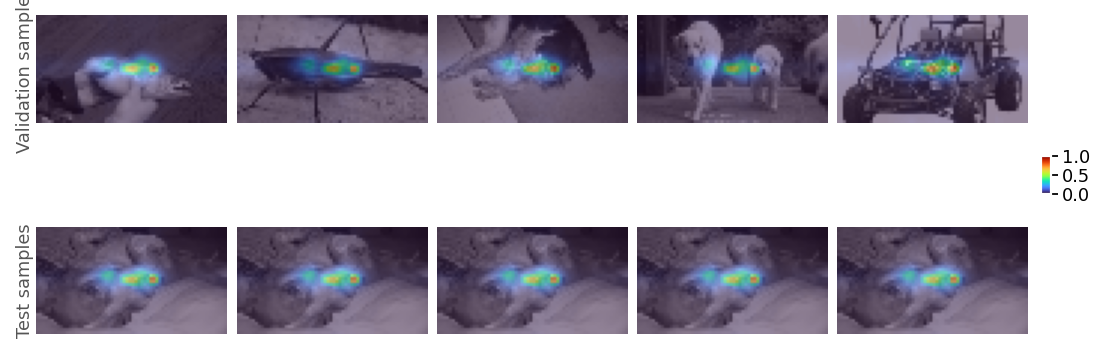

In [21]:
mouse_id = "k_4_a_03_xyz_b1e7_poisson"

plot_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    num_images=5,
    l=0,
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

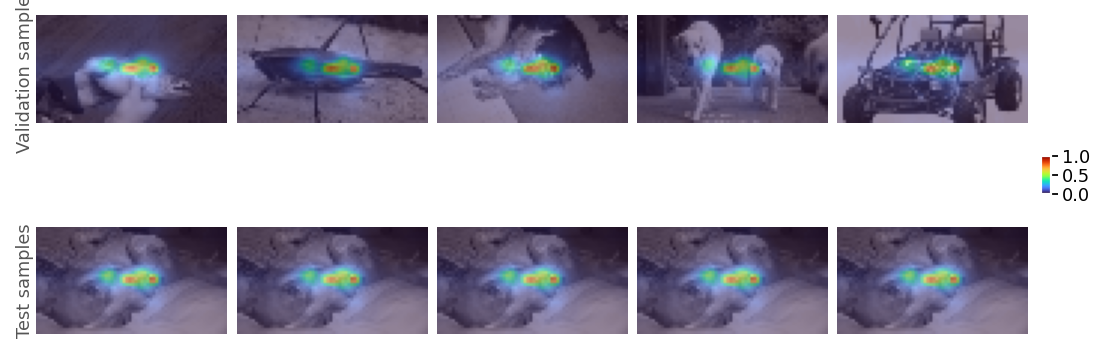

In [22]:
mouse_id = "k_4_a_03_xyz_b1e7_poisson"

plot_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    num_images=5,
    l=1,
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

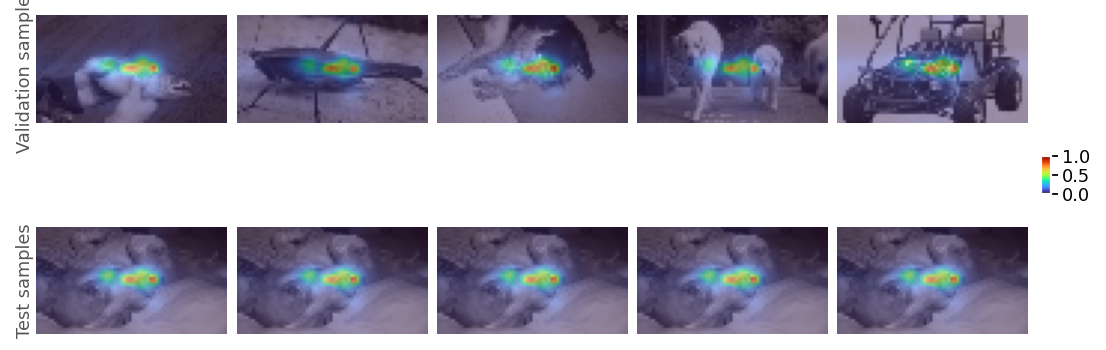

In [23]:
mouse_id = "k_4_a_03_xyz_b1e7_poisson"

plot_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    num_images=5,
    l=2,
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

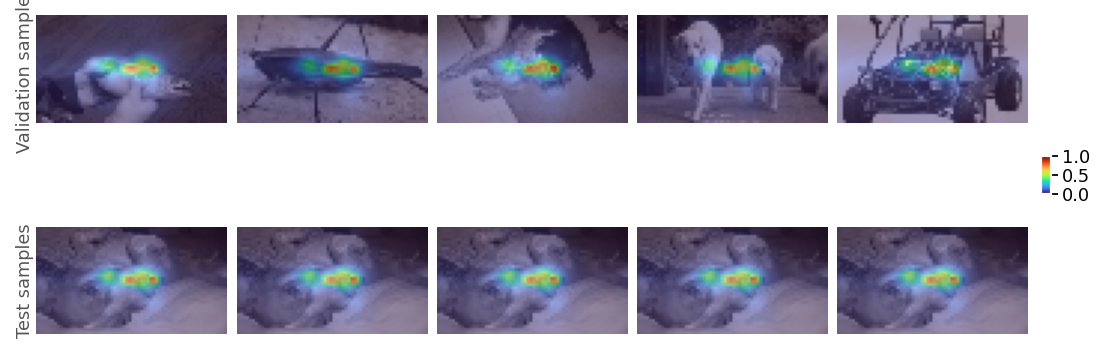

In [24]:
mouse_id = "k_4_a_03_xyz_b1e7_poisson"

plot_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    num_images=5,
    l=3,
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

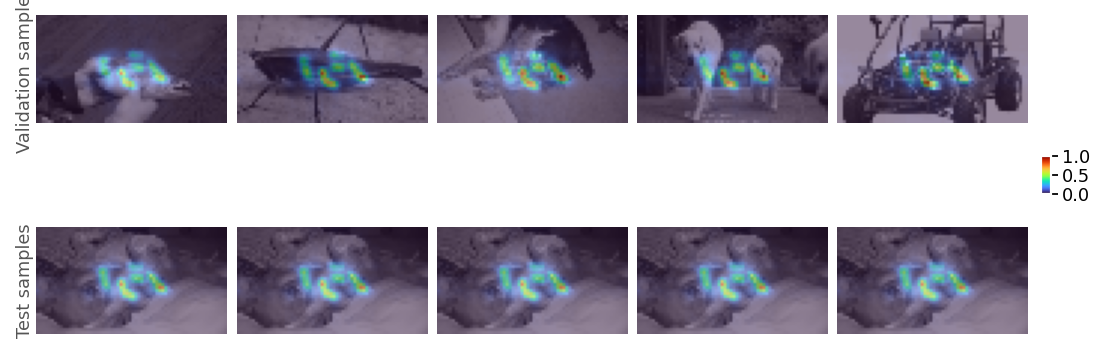

In [17]:
mouse_id = "k_4_a_03_b1e7_poisson"

plot_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    num_images=5,
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

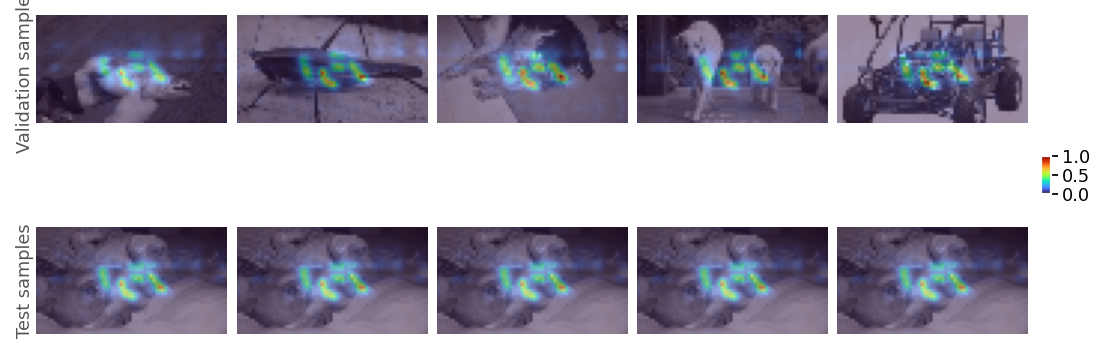

In [11]:
mouse_id = "k_4_a_03_b1e7_poisson"

plot_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    num_images=5,
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

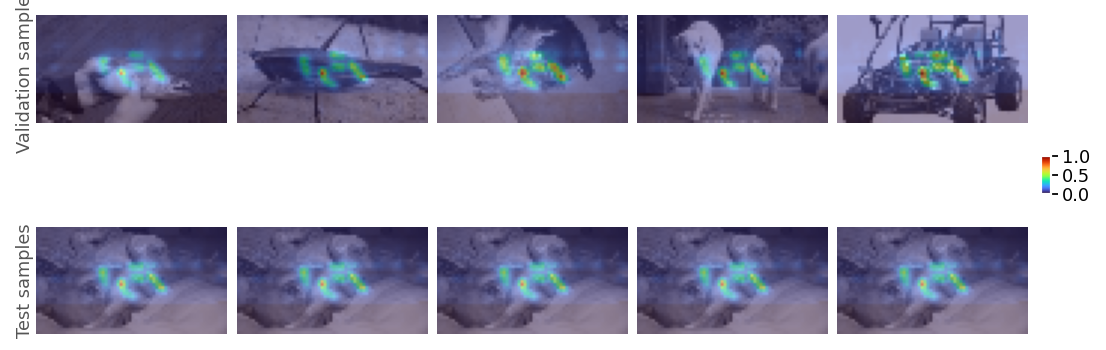

In [8]:
mouse_id = "k_4_a_03_b1e7_poisson"

plot_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    num_images=5,
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

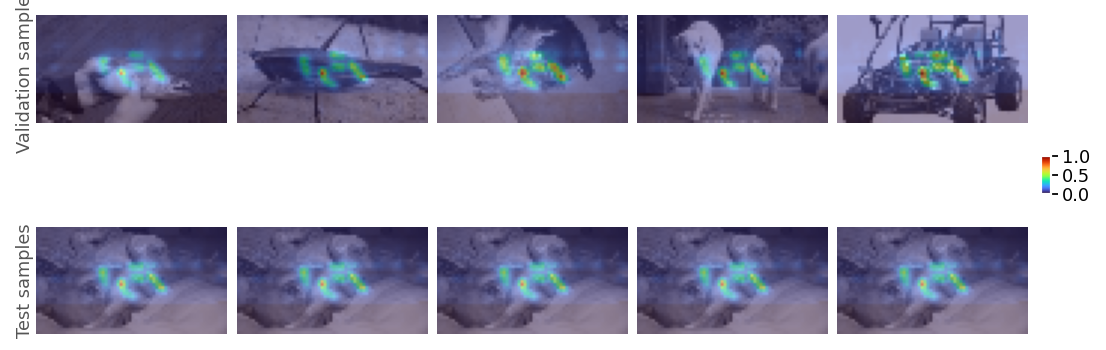

In [8]:
mouse_id = "k_4_a_03_b1e7_poisson"

plot_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    num_images=5,
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

## Maps: neurons to images

In [9]:
def plot_neuron_attention_maps(
    val_results: t.Dict[str, np.ndarray],
    test_results: t.Dict[str, np.ndarray],
    filename: str = None,
    colormap: str = "turbo",
    alpha: float = 0.5,
    num_images: int = 3,
    heatmaps: str = "readout_query_to_image_maps",
    neuron_type: str = "query"
):
    cmap = matplotlib.colormaps.get_cmap(colormap)
    colors = cmap(np.arange(256))[:, :3]
    label_fontsize, tick_fontsize = 10, 8
    x_labelpad, y_labelpad = 2, 1
    figure, axes = plt.subplots(
        nrows=2,
        ncols=num_images,
        figsize=(8, 4),
        gridspec_kw={"wspace": 0.05, "hspace": -0.25},
        dpi=160,
    )
    for i in range(num_images):
        image = val_results["images"][0]
        heatmap = val_results[heatmaps][0, i]
        neuron_idx = val_results[neuron_type+"_neuron_ids"][0][i]
        gray_image = image.shape[0] == 1
        image = image[0] if gray_image else to_rgb(image)
        heatmap = colors[np.uint8(255.0 * heatmap)] * 255.0
        image = image[..., None] if gray_image else image
        heatmap = alpha * heatmap + (1 - alpha) * image
        # heatmap = heatmap * image
        axes[0, i].imshow(heatmap.astype(np.uint8), cmap=colormap)
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])
        tensorboard.remove_spines(axis=axes[0, i])
        description = (
            f"idx: {neuron_idx}"
        )
        axes[0, i].set_xlabel(description, labelpad=x_labelpad, fontsize=tick_fontsize)
    axes[0, 0].set_ylabel(
        "Validation samples", labelpad=y_labelpad, fontsize=tick_fontsize
    )
    for i in range(num_images):
        image = test_results["images"][0]
        heatmap = test_results[heatmaps][0, i]
        neuron_idx = test_results[neuron_type+"_neuron_ids"][0][i]
        gray_image = image.shape[0] == 1
        image = image[0] if gray_image else to_rgb(image)
        heatmap = colors[np.uint8(255.0 * heatmap)] * 255.0
        image = image[..., None] if gray_image else image
        heatmap = alpha * heatmap + (1 - alpha) * image
        # heatmap = heatmap * image
        axes[1, i].imshow(heatmap.astype(np.uint8), cmap=colormap)
        axes[1, i].set_xticks([])
        axes[1, i].set_yticks([])
        tensorboard.remove_spines(axis=axes[1, i])
        description = (
            f"idx: {neuron_idx}"
        )
        axes[1, i].set_xlabel(description, labelpad=x_labelpad, fontsize=tick_fontsize)
    axes[-1, 0].set_ylabel("Test samples", labelpad=y_labelpad, fontsize=tick_fontsize)

    # plot colorbar
    pos1 = axes[0, -1].get_position()
    pos2 = axes[-1, -1].get_position()
    width, height = 0.008, (pos1.y1 - pos1.y0) * 0.35
    cbar_ax = figure.add_axes(
        rect=[
            pos1.x1 + 0.01,
            ((pos1.y1 - pos2.y0) / 2 + pos2.y0) - (height / 2),
            width,
            height,
        ]
    )
    figure.colorbar(cm.ScalarMappable(cmap=colormap), cax=cbar_ax, shrink=0.1)
    tensorboard.set_yticks(
        axis=cbar_ax,
        ticks_loc=np.linspace(0, 1, 3),
        tick_fontsize=tick_fontsize,
    )
    tensorboard.set_ticks_params(axis=cbar_ax)

    if filename is not None:
        tensorboard.save_figure(figure, filename=filename, dpi=240, close=False)

    plt.show()
    plt.close(figure)


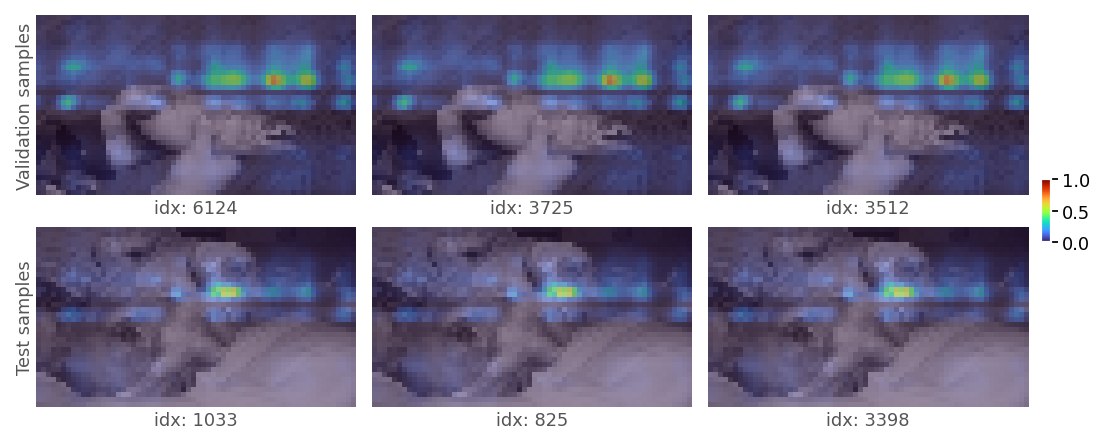

In [14]:
mouse_id = "k_4_a_03_b1e7_poisson"

plot_neuron_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    num_images=3,
    heatmaps="core_neuron_to_image_rollout_maps",
    neuron_type="input",
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

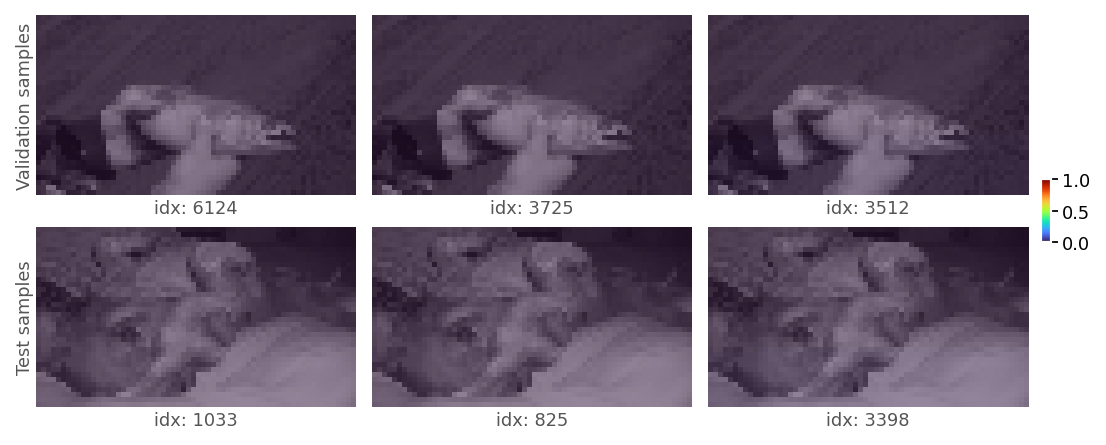

In [17]:
mouse_id = "k_4_a_03_b1e7_poisson"

plot_neuron_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    num_images=3,
    heatmaps="core_neuron_to_image_rollout_maps",
    neuron_type="input",
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

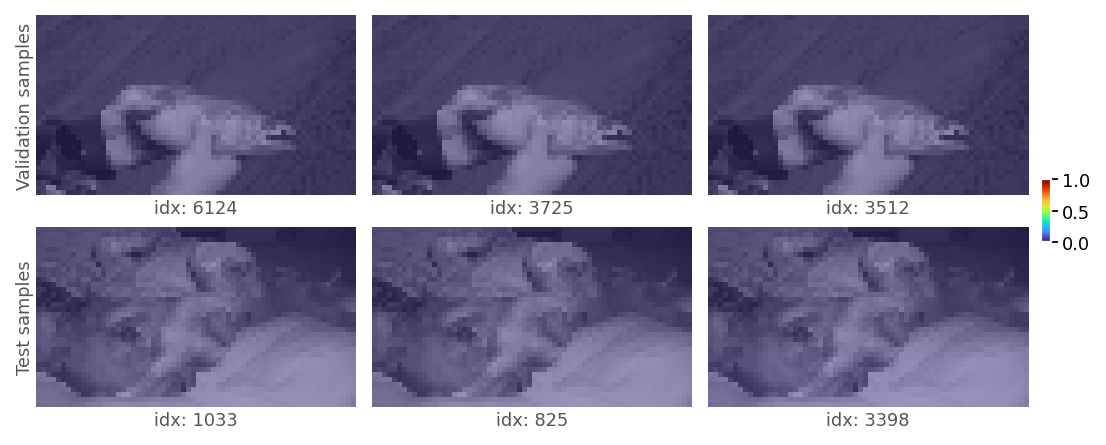

In [10]:
mouse_id = "k_4_a_03_b1e7_poisson"

plot_neuron_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    num_images=3,
    heatmaps="core_neuron_to_image_rollout_maps",
    neuron_type="input",
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

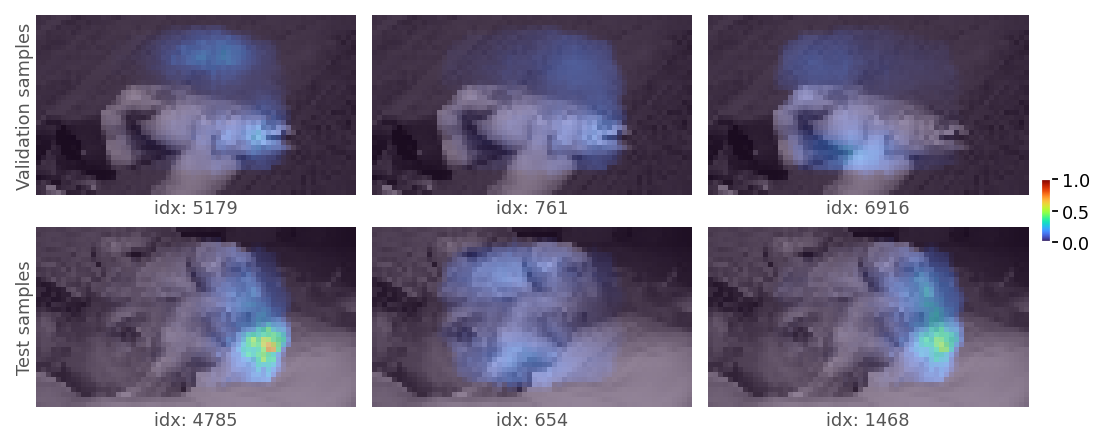

In [15]:
mouse_id = "k_4_a_03_b1e7_poisson"

plot_neuron_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

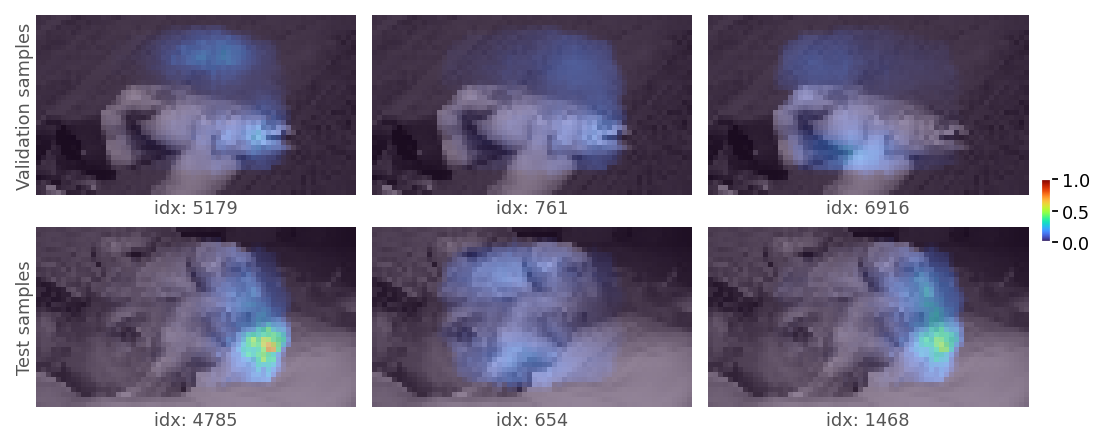

In [14]:
mouse_id = "k_4_a_03_b1e7_poisson"

plot_neuron_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

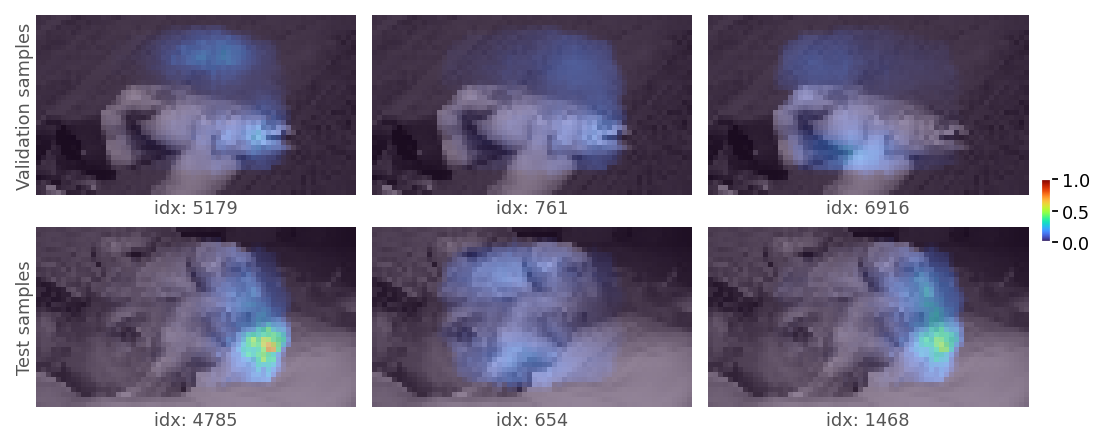

In [11]:
mouse_id = "k_4_a_03_b1e7_poisson"

plot_neuron_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    # filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)

In [24]:
gain = np.load("/user/azhar.akhmetova/sensorium_clusters/syn_data_generation/beta10e7/23343-5-17/k_4/gain_k_4.npy")

## Maps: neurons to neurons

In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from typing import Literal, Dict

# ----------------------------- utils -----------------------------

def _to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

# ----------------------------- 1) coord sorting -----------------------------

def order_coords(
    token_ids: np.ndarray,
    neuron_coordinates: np.ndarray,   # [N, >=2] global, id-sorted 0..N-1
    mode: Literal["xy","yx"] = "xy",
) -> np.ndarray:
    """
    Return an index array that reorders `token_ids` lexicographically by coords:
      - "xy" -> sort by x then y
      - "yx" -> sort by y then x
    """
    token_ids = np.asarray(token_ids).astype(int)
    print(neuron_coordinates.shape)
    coords = _to_np(neuron_coordinates)[token_ids]   # [K, d]
    
    if coords.shape[1] < 2:
        raise ValueError(f"coords need at least 2 columns (x,y); got shape {coords.shape}")

    if mode == "xy":
        # np.lexsort sorts by last key first, so (y, x) means x primary, then y
        order = np.lexsort((coords[:, 1], coords[:, 0]))
    elif mode == "yx":
        order = np.lexsort((coords[:, 0], coords[:, 1]))
    else:
        raise ValueError(f"Unknown mode {mode}")
    return order

# ----------------------------- 2) embedding sorting -----------------------------

def order_emb_ref0(
    token_ids: np.ndarray,
    id_embeddings: torch.Tensor | np.ndarray,   # [N, D] global, id-sorted 0..N-1
    eps: float = 1e-8,
) -> np.ndarray:
    """
    Return an index array that reorders `token_ids` by cosine similarity
    to the GLOBAL reference embedding with id == 0. Descending similarity.
    """
    token_ids = np.asarray(token_ids).astype(int)
    E = _to_np(id_embeddings)              # [N, D]
    if E.ndim != 2 or E.shape[0] <= 0:
        raise ValueError(f"Bad id_embeddings shape {E.shape}")

    ref = E[0].astype(np.float64, copy=False)         # [D]
    ref /= (np.linalg.norm(ref) + eps)

    emb_sub = E[token_ids].astype(np.float64, copy=False)  # [K, D]
    norms = np.linalg.norm(emb_sub, axis=1, keepdims=True)
    norms = np.maximum(norms, eps)
    emb_unit = emb_sub / norms

    sim = emb_unit @ ref     # [K]
    order = np.argsort(-sim) # descending cosine similarity
    return order

# ----------------------------- 3) plotting -----------------------------

def _get_orders(
    ordering_type: Literal["coords_xy","coords_yx","emb_ref0"],
    token_ids: np.ndarray,
    neuron_coordinates: np.ndarray,
    id_embeddings: torch.Tensor | np.ndarray,
) -> np.ndarray:
    if ordering_type == "coords_xy":
        return order_coords(token_ids, neuron_coordinates, mode="xy")
    if ordering_type == "coords_yx":
        return order_coords(token_ids, neuron_coordinates, mode="yx")
    if ordering_type == "emb_ref0":
        return order_emb_ref0(token_ids, id_embeddings)
    raise ValueError(f"Unknown ordering_type: {ordering_type}")

def plot_attention_heatmap(
    results: Dict[str, np.ndarray],
    key: Literal[
        "core_neuron_to_neuron_maps",
        "core_neuron_to_neuron_rollout_maps",
        "readout_query_to_neuron_maps",
    ],
    *,
    id_embeddings: torch.Tensor | np.ndarray,   # [N, D], global id-sorted
    neuron_coordinates: np.ndarray,             # [N, >=2], global id-sorted
    batch_idx: int = 0,
    # Choose ordering(s)
    core_ordering: Literal["coords_xy","coords_yx","emb_ref0"] = "coords_xy",
    query_ordering: Literal["coords_xy","coords_yx","emb_ref0"] | None = None,
    input_ordering: Literal["coords_xy","coords_yx","emb_ref0"] | None = None,
    # viz
    vmin: float | None = None,
    vmax: float | None = None,
    cmap: str = "turbo",
    title: str | None = None,
    tick_max: int = 12,
):
    """
    Plots either:
      - CORE: [B, K, K] -> rows/cols are the same input-token set; applies `core_ordering`
      - READOUT: [B, Nq, K] -> rows=query, cols=input; applies `query_ordering` and `input_ordering`
        (if None, they default to `core_ordering`).

    Tick labels show the actual neuron ids after reordering.
    """
    M = _to_np(results[key][batch_idx])
    if M.ndim != 2:
        raise ValueError(f"Expected 2D map after indexing batch; got shape {M.shape}")

    # Decide core vs readout by shape
    is_square = (M.shape[0] == M.shape[1])

    if is_square:
        # -------- CORE: use input_neuron_ids on both axes --------
        input_ids = _to_np(results["input_neuron_ids"][batch_idx]).astype(int)  # [K]
        order = _get_orders(core_ordering, input_ids, neuron_coordinates, id_embeddings)
        M_sorted = M[np.ix_(order, order)]
        ids_sorted = input_ids[order]

        K = len(ids_sorted)
        step = max(1, int(np.ceil(K / tick_max)))
        ticks = np.arange(0, K, step)

        plt.figure(figsize=(5, 4.2), dpi=150)
        im = plt.imshow(M_sorted, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
        ttl = title or f"{key} • order={core_ordering}"
        plt.title(ttl)
        plt.xlabel("input neuron ids (sorted)")
        plt.ylabel("input neuron ids (sorted)")
        plt.xticks(ticks, ids_sorted[ticks], rotation=90, fontsize=7)
        plt.yticks(ticks, ids_sorted[ticks], fontsize=7)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    else:
        # -------- READOUT: rows=query, cols=input --------
        query_ids = _to_np(results["query_neuron_ids"][batch_idx]).astype(int)  # [Nq]
        input_ids = _to_np(results["input_neuron_ids"][batch_idx]).astype(int)  # [K]

        if query_ordering is None:
            query_ordering = core_ordering
        if input_ordering is None:
            input_ordering = core_ordering

        q_order = _get_orders(query_ordering, query_ids, neuron_coordinates, id_embeddings)
        k_order = _get_orders(input_ordering, input_ids, neuron_coordinates, id_embeddings)

        M_sorted = M[np.ix_(q_order, k_order)]
        q_ids_sorted = query_ids[q_order]
        k_ids_sorted = input_ids[k_order]

        Nq, K = M_sorted.shape
        q_step = max(1, int(np.ceil(Nq / tick_max)))
        k_step = max(1, int(np.ceil(K / tick_max)))
        q_ticks = np.arange(0, Nq, q_step)
        k_ticks = np.arange(0, K, k_step)

        plt.figure(figsize=(6.2, 4.2), dpi=150)
        im = plt.imshow(M_sorted, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto", interpolation="nearest")
        ttl = title or f"{key} • rows={query_ordering}, cols={input_ordering}"
        plt.title(ttl)
        plt.xlabel("input neuron ids (sorted)")
        plt.ylabel("query neuron ids (sorted)")
        plt.xticks(k_ticks, k_ids_sorted[k_ticks], rotation=90, fontsize=7)
        plt.yticks(q_ticks, q_ids_sorted[q_ticks], fontsize=7)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()


torch.Size([7334, 3])


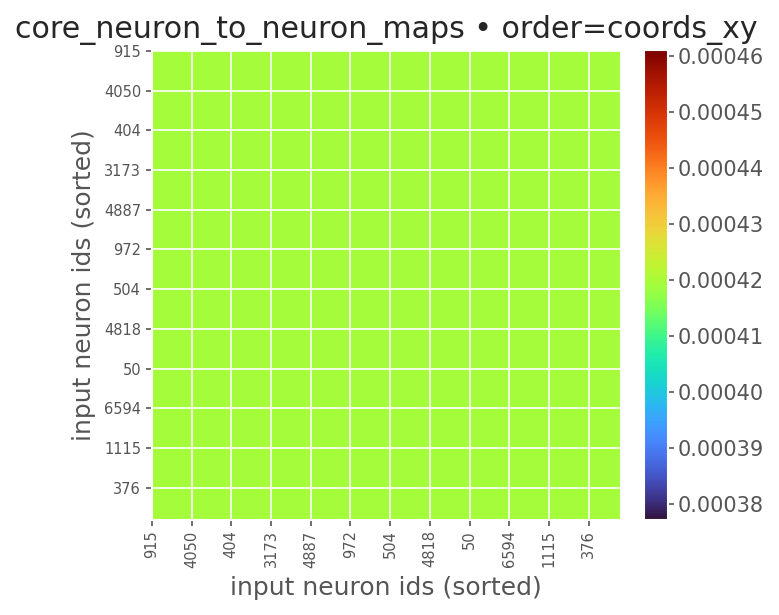

torch.Size([7334, 3])


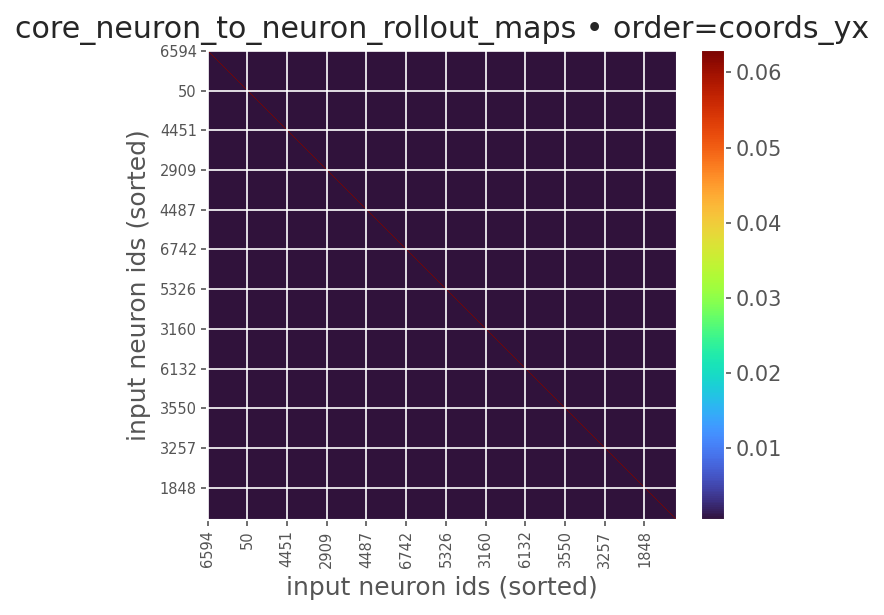

torch.Size([7334, 3])


IndexError: index 300 is out of bounds for axis 1 with size 0

In [20]:
# CORE last-layer, order by x→y
plot_attention_heatmap(
    results["validation"]["k_4_a_03_b1e7_poisson"],
    key="core_neuron_to_neuron_maps",
    id_embeddings=id_embeddings,
    neuron_coordinates=results["validation"]["k_4_a_03_b1e7_poisson"]["neuron_coordinates"][0],
    core_ordering="coords_xy",
    cmap="turbo"
)

# CORE rollout, order by y→x
plot_attention_heatmap(
    results["validation"]["k_4_a_03_b1e7_poisson"],
    key="core_neuron_to_neuron_rollout_maps",
    id_embeddings=id_embeddings,
    neuron_coordinates=results["validation"]["k_4_a_03_b1e7_poisson"]["neuron_coordinates"][0],
    core_ordering="coords_yx",
)

# READOUT query→input, rows by cosine-to-ref0, cols by x→y
plot_attention_heatmap(
    results["validation"]["k_4_a_03_b1e7_poisson"],
    key="readout_query_to_neuron_maps",
    id_embeddings=id_embeddings,
    neuron_coordinates=results["validation"]["k_4_a_03_b1e7_poisson"]["neuron_coordinates"][0],
    query_ordering="emb_ref0",
    input_ordering="coords_xy",
    cmap="turbo"
)


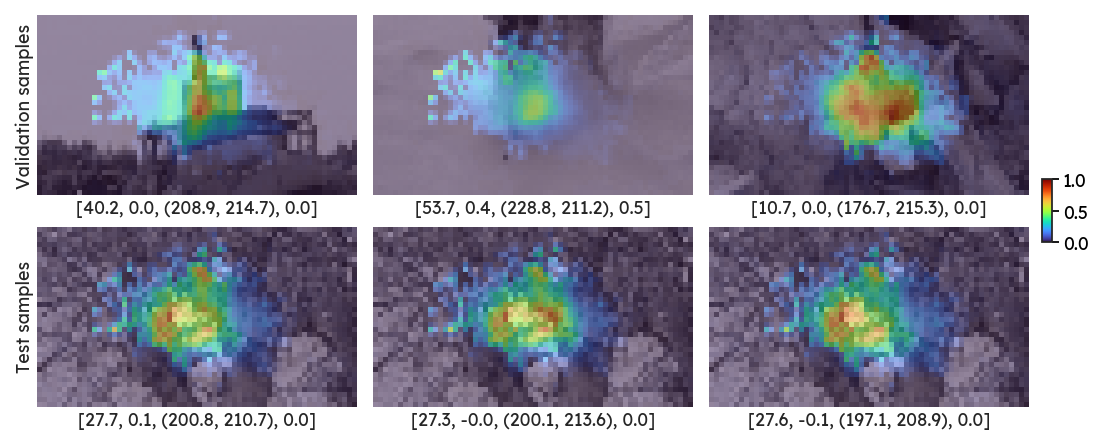

In [50]:
mouse_id = "E"

plot_attention_maps(
    val_results=results["validation"][mouse_id],
    test_results=results["test"][mouse_id],
    filename=os.path.join(PLOT_DIR, f"attention_rollout_mouse{mouse_id}.pdf"),
)